# Exploratory Data Analysis (EDA)

## Objective

This notebook explores customer behavior, sales trends, and operational patterns using the processed e-commerce dataset.

Key goals:
- Understand revenue and order trends
- Analyze customer purchasing behavior
- Identify potential churn indicators
- Generate actionable business insights

# Import Libraries

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)

sns.set(style="whitegrid")

# Load Processed Dataset

In [3]:
df = pd.read_csv("/kaggle/input/datasets/poemshijin/customeranalyticssalesintelligence-olist-dataset/processed_master_dataset.csv")

# Convert Datetime

In [4]:
df['order_purchase_timestamp'] = pd.to_datetime(df['order_purchase_timestamp'])

# Revenue Trend Analysis

Monthly Revenue

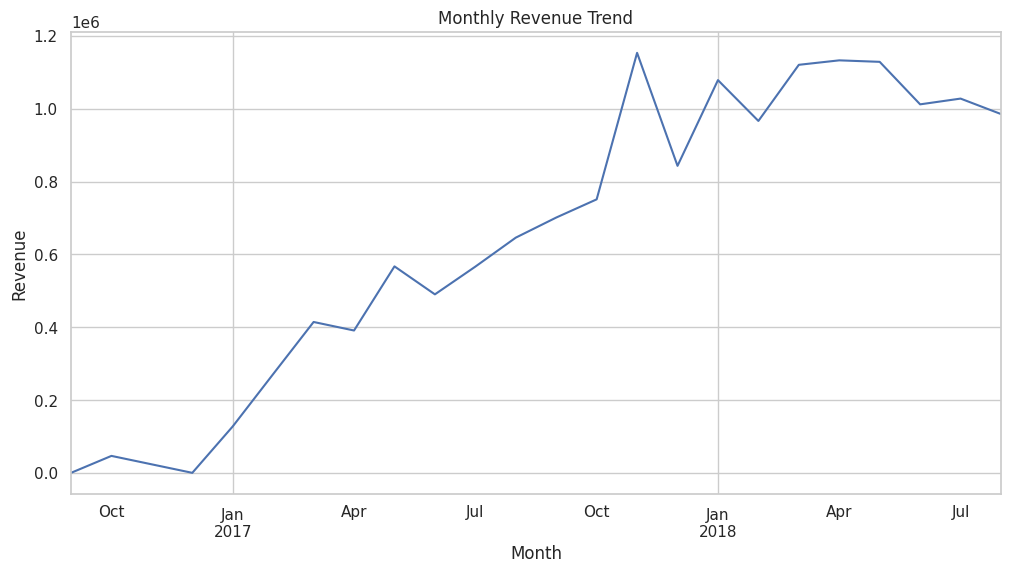

In [5]:
monthly_revenue = df.groupby(
    df['order_purchase_timestamp'].dt.to_period('M')
)['order_value'].sum()

monthly_revenue.plot(figsize=(12,6))

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")

plt.show()

## Revenue Trend Insight

- Revenue increased significantly throughout 2017
- Strong peaks are visible during holiday and promotional periods
- Revenue stabilizes during 2018 before declining sharply near the dataset end

Possible explanation:
- The final decline is likely caused by incomplete data collection rather than actual business contraction

# Order Volume Analysis

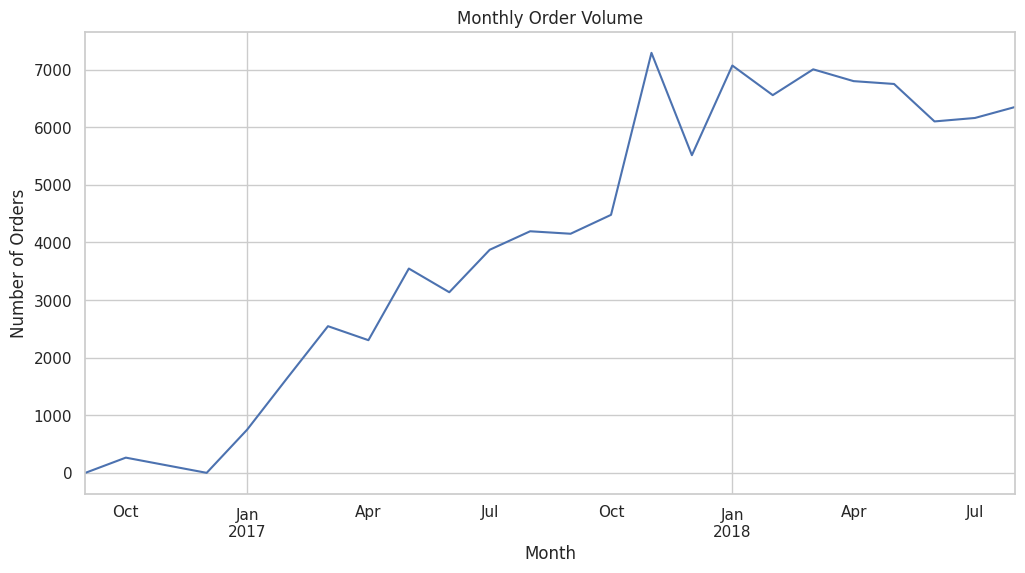

In [6]:
monthly_orders = df.groupby(
    df['order_purchase_timestamp'].dt.to_period('M')
)['order_id'].nunique()

monthly_orders.plot(figsize=(12,6))

plt.title("Monthly Order Volume")
plt.xlabel("Month")
plt.ylabel("Number of Orders")

plt.show()

# Customer Purchase Behavior

Distribution of Orders per Customer

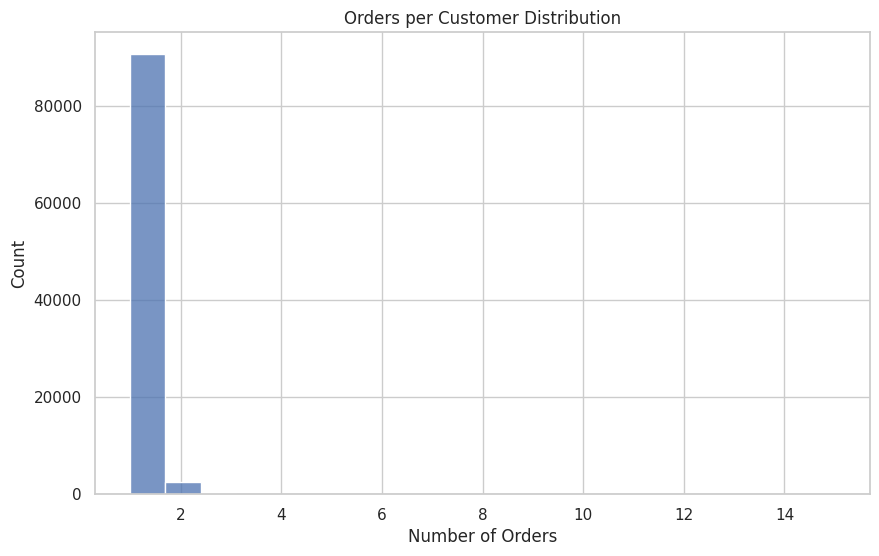

In [7]:
customer_order_dist = df.groupby('customer_unique_id')['order_id'].nunique()

plt.figure(figsize=(10,6))

sns.histplot(customer_order_dist, bins=20)

plt.title("Orders per Customer Distribution")
plt.xlabel("Number of Orders")

plt.show()

## Customer Behavior Insight

- Most customers made only one purchase
- Repeat purchase behavior is relatively limited

Business implication:
- Customer retention may be a key business challenge
- Loyalty and retention strategies could improve long-term revenue

# Order Value Analysis

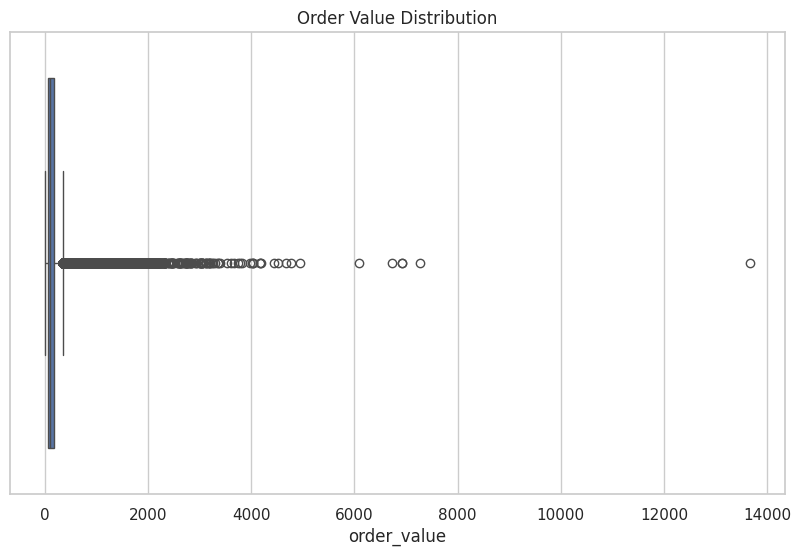

In [8]:
plt.figure(figsize=(10,6))

sns.boxplot(x=df['order_value'])

plt.title("Order Value Distribution")

plt.show()

## Order Value Insight

- Most orders fall within a moderate price range
- Several high-value outliers exist

Possible explanation:
- High-value orders may represent premium products or bulk purchases
- Outliers should be monitored carefully during modeling

# Delivery Time Analysis

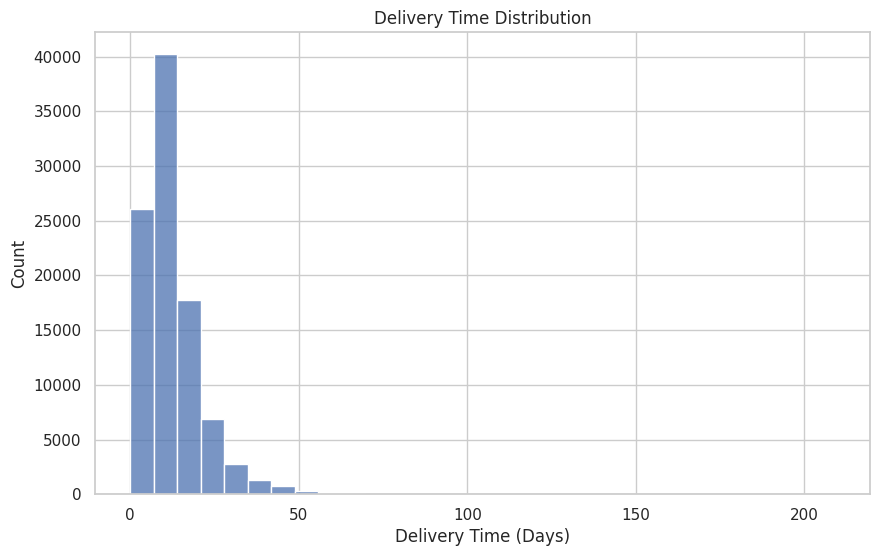

In [9]:
plt.figure(figsize=(10,6))

sns.histplot(df['delivery_time'].dropna(), bins=30)

plt.title("Delivery Time Distribution")
plt.xlabel("Delivery Time (Days)")

plt.show()

## Delivery Performance Insight

- Most deliveries are completed within a reasonable timeframe
- Some extreme delivery delays are present

Business implication:
- Delivery efficiency impacts customer satisfaction
- Long delays may contribute to churn risk

# Payment Behavior

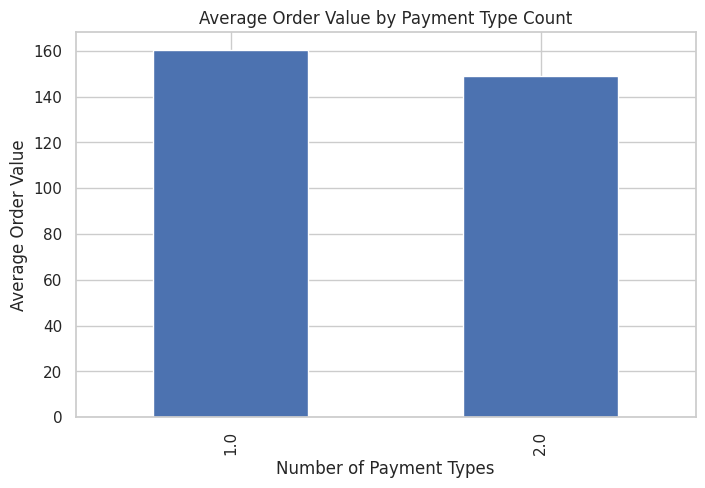

In [10]:
payment_summary = df.groupby('payment_types')['order_value'].mean()

payment_summary.plot(kind='bar', figsize=(8,5))

plt.title("Average Order Value by Payment Type Count")
plt.xlabel("Number of Payment Types")
plt.ylabel("Average Order Value")

plt.show()

# Top States by Revenue

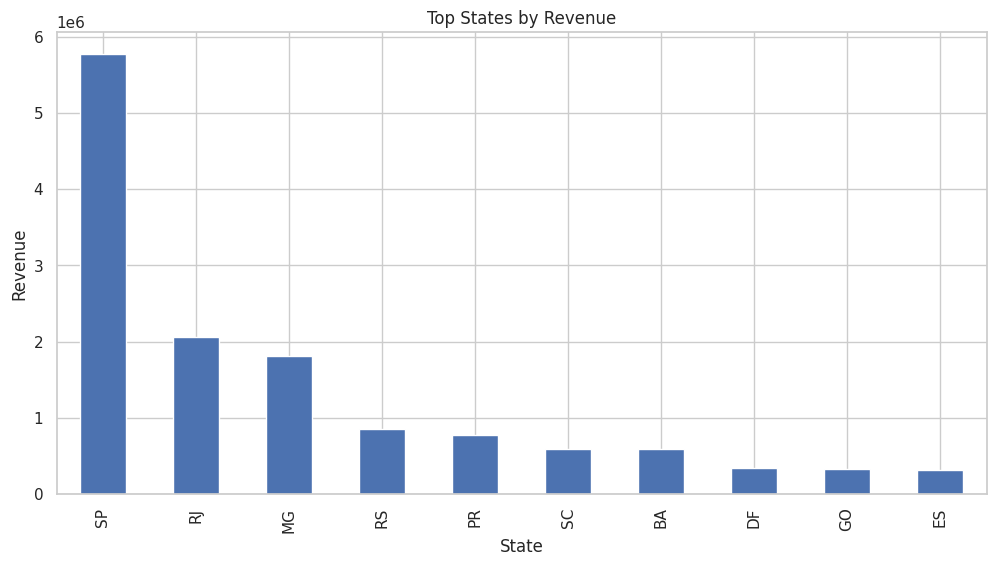

In [11]:
top_states = df.groupby('customer_state')['order_value'].sum().sort_values(ascending=False).head(10)

top_states.plot(kind='bar', figsize=(12,6))

plt.title("Top States by Revenue")
plt.xlabel("State")
plt.ylabel("Revenue")

plt.show()

## Geographic Revenue Insight

- Revenue is concentrated in a few major states
- Geographic concentration may indicate:
  - stronger logistics infrastructure
  - higher population density
  - stronger purchasing power

# Correlation Analysis

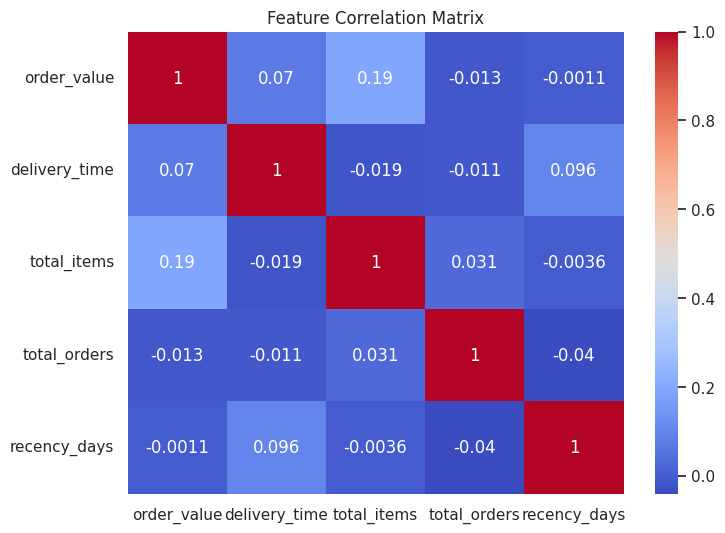

In [12]:
numeric_cols = [
    'order_value',
    'delivery_time',
    'total_items',
    'total_orders',
    'recency_days'
]

corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(8,6))

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')

plt.title("Feature Correlation Matrix")

plt.show()

## Correlation Insight

- Some customer activity features show moderate relationships with order value
- No extremely strong linear correlations are observed

Implication:
- Customer behavior is likely influenced by multiple interacting factors
- Non-linear models may perform better during machine learning

# Final EDA Summary

# EDA Summary

Key findings:

1. Revenue and order volume grew strongly throughout 2017
2. Most customers made only one purchase
3. Delivery performance varies significantly across orders
4. Revenue is concentrated in major geographic regions
5. Customer retention appears to be a critical business opportunity

Next steps:
- Build machine learning models for churn prediction
- Segment customers by purchasing behavior
- Develop dashboards for business monitoring